# Natural Language Processing Coursework

## Setup

In [15]:


import os
if not os.path.exists("NLPLabs-2024"):
    !git clone -q https://github.com/CRLala/NLPLabs-2024.git


if not os.path.exists("dontpatronizeme"):
    !git clone -q https://github.com/Perez-AlmendrosC/dontpatronizeme.git

    
pcl_tsv_path = "NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
train_split_path = "dontpatronizeme/semeval-2022/practice splits/train_semeval_parids-labels.csv"
dev_split_path   = "dontpatronizeme/semeval-2022/practice splits/dev_semeval_parids-labels.csv"


In [24]:
import os
from pathlib import Path
import re
import csv
import numpy as np
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [20]:

rows = []
with open(pcl_tsv_path, "r", encoding="utf-8", newline="") as f:
    r = csv.reader(f, delimiter="\t")
    for parts in r:
        if not parts:
            continue

        # skip boilerplate/disclaimer lines
        if len(parts) == 1:
            continue

        # expect 6 columns for real data
        if len(parts) != 6:
            raise ValueError(f"Unexpected number of columns: {len(parts)} | {parts[:3]}")

        pid, article_id, keyword, country, paragraph, label = parts
        rows.append({
            "paragraph_id": str(pid),
            "article_id": str(article_id),
            "keyword": str(keyword),
            "country_code": str(country),
            "paragraph": str(paragraph),
            "label_orig": int(label),
            "label_binary": 1 if int(label) >= 2 else 0,
        })

df = pd.DataFrame(rows)
df.head()

,paragraph_id,article_id,keyword,country_code,paragraph,label_orig,label_binary
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0,0


In [10]:
train_split = pd.read_csv(train_split_path)
dev_split   = pd.read_csv(dev_split_path)

train_ids = set(train_split.iloc[:, 0].astype(str))
dev_ids   = set(dev_split.iloc[:, 0].astype(str))

df_train = df[df["paragraph_id"].isin(train_ids)].reset_index(drop=True)
df_dev   = df[df["paragraph_id"].isin(dev_ids)].reset_index(drop=True)

print("All:", len(df), "Train:", len(df_train), "Dev:", len(df_dev))

All: 10469 Train: 8375 Dev: 2094


## 2. EDA

### 2.1. Basic Statistical Profiling

Class distribution (binary) — Train


,label,count
0,0,7581
1,1,794


Class distribution (binary) — Dev


,label,count
0,0,1895
1,1,199


Class distribution (original 0..4) — Train


,label_orig,count
0,0,6825
1,1,756
2,2,126
3,3,369
4,4,299


Token-count summary (overall)


,train_all,dev_all
count,8375.000000,2094.000000
mean,43.405970,42.344317
std,26.504921,23.938653
min,1.000000,0.000000
25%,27.000000,26.000000
50%,38.000000,37.000000
75%,54.000000,52.000000
max,819.000000,259.000000
0.5,38.000000,37.000000
0.9,75.000000,73.000000


Token-count summary by label (train)


,label_binary,count,mean,std,min,50%,90%,95%,99%,max
0,0,7581.0,42.943411,26.043916,1.0,37.0,74.0,90.0,126.0,819.0
1,1,794.0,47.822418,30.222211,6.0,41.0,82.7,103.0,131.0,457.0


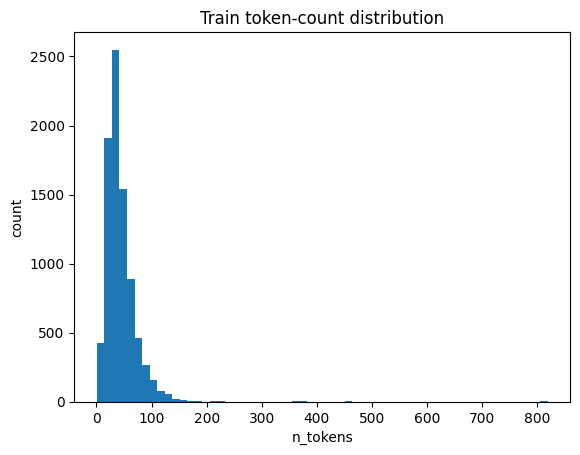

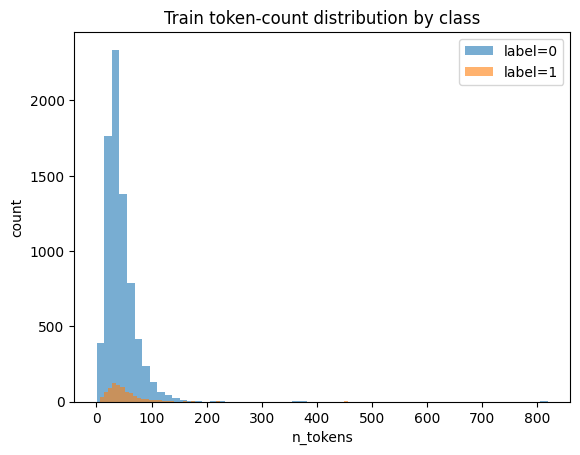

Vocabulary report


,train_vocab_size,dev_vocab_size,dev_tokens_total,dev_vocab_oov_vs_train,dev_token_oov_rate_vs_train
0,26073,12132,88669,3018,0.038356


Top 30 most frequent train tokens (simple tokenizer, incl. stopwords)


,token,count
0,the,20860
1,to,11445
2,of,11225
3,and,10303
4,in,8850
5,a,7357
6,for,3944
7,that,3898
8,is,3630
9,s,2774


In [25]:
TEXT_COL = "paragraph"
LABEL_COL = "label_binary"

_WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")

def simple_tokenize(s: str):
    return _WORD_RE.findall(str(s).lower())

def with_basic_stats(df: pd.DataFrame, text_col=TEXT_COL):
    out = df.copy()
    out["n_chars"] = out[text_col].astype(str).str.len()
    tok_lists = out[text_col].astype(str).apply(simple_tokenize)
    out["n_tokens"] = tok_lists.apply(len)
    out["n_words_ws"] = out[text_col].astype(str).str.split().apply(len)
    return out, tok_lists

df_train_stats, train_toks = with_basic_stats(df_train)
df_dev_stats, dev_toks     = with_basic_stats(df_dev)


# ---- (A) Class distributions (binary + original)
print("Class distribution (binary) — Train")
display(df_train_stats[LABEL_COL].value_counts(dropna=False).rename_axis("label").reset_index(name="count"))

print("Class distribution (binary) — Dev")
display(df_dev_stats[LABEL_COL].value_counts(dropna=False).rename_axis("label").reset_index(name="count"))

if "label_orig" in df_train_stats.columns:
    print("Class distribution (original 0..4) — Train")
    display(df_train_stats["label_orig"].value_counts().sort_index().rename_axis("label_orig").reset_index(name="count"))

# ---- (B) Length summaries (token counts)
def length_summary(df_stats: pd.DataFrame, group_name: str):
    q = df_stats["n_tokens"].quantile([0.5, 0.9, 0.95, 0.99]).rename(group_name)
    desc = df_stats["n_tokens"].describe().rename(group_name)
    return pd.concat([desc, q])

summary_all = pd.concat([
    length_summary(df_train_stats, "train_all"),
    length_summary(df_dev_stats, "dev_all"),
], axis=1)

print("Token-count summary (overall)")
display(summary_all)

summary_by_label = (
    df_train_stats
    .groupby(LABEL_COL)["n_tokens"]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .reset_index()
)

print("Token-count summary by label (train)")
display(summary_by_label)

# ---- (C) Length distribution plots
plt.figure()
plt.hist(df_train_stats["n_tokens"], bins=60)
plt.title("Train token-count distribution")
plt.xlabel("n_tokens")
plt.ylabel("count")
plt.show()

plt.figure()
for lab in sorted(df_train_stats[LABEL_COL].unique()):
    subset = df_train_stats[df_train_stats[LABEL_COL] == lab]["n_tokens"]
    plt.hist(subset, bins=60, alpha=0.6, label=f"label={lab}")
plt.title("Train token-count distribution by class")
plt.xlabel("n_tokens")
plt.ylabel("count")
plt.legend()
plt.show()

# ---- (D) Vocabulary size + dev OOV rate vs train vocab
train_counter = Counter()
for toks in train_toks:
    train_counter.update(toks)
train_vocab = set(train_counter.keys())

dev_counter = Counter()
for toks in dev_toks:
    dev_counter.update(toks)
dev_vocab = set(dev_counter.keys())

vocab_report = pd.DataFrame([{
    "train_vocab_size": len(train_vocab),
    "dev_vocab_size": len(dev_vocab),
    "dev_tokens_total": sum(dev_counter.values()),
    "dev_vocab_oov_vs_train": len(dev_vocab - train_vocab),
    "dev_token_oov_rate_vs_train": (
        sum(cnt for tok, cnt in dev_counter.items() if tok not in train_vocab) / max(1, sum(dev_counter.values()))
    ),
}])

print("Vocabulary report")
display(vocab_report)

print("Top 30 most frequent train tokens (simple tokenizer, incl. stopwords)")
display(pd.DataFrame(train_counter.most_common(30), columns=["token", "count"]))

### Lexical Analysis

Stopword ratio summary (train) overall


,stopword_ratio
count,8375.000000
mean,0.461392
std,0.094325
min,0.000000
25%,0.404255
50%,0.464286
75%,0.523810
max,0.758621


Stopword ratio summary (train) by label


,label_binary,count,mean,std,min,25%,50%,75%,max
0,0,7581.0,0.458501,0.093643,0.0,0.400000,0.461538,0.520000,0.750000
1,1,794.0,0.488988,0.096399,0.0,0.423368,0.491794,0.555556,0.758621


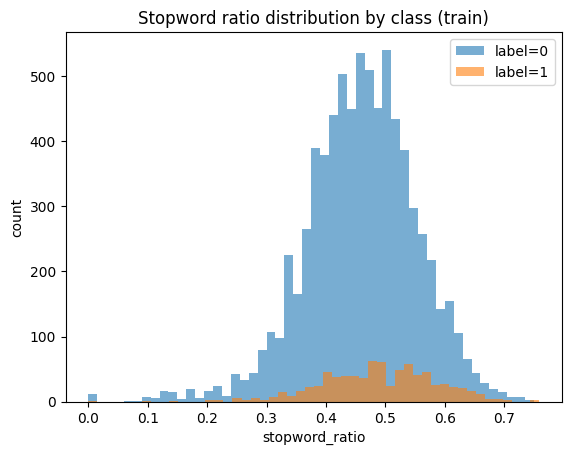

Top n-grams (more frequent in PCL=1)


,ngram,mean_count_pos,mean_count_neg,diff
0,need,0.248111,0.115288,0.132823
1,poor,0.229219,0.102229,0.126990
2,children,0.209068,0.084290,0.124778
3,people,0.268262,0.170558,0.097704
4,homeless,0.186398,0.089434,0.096964
5,help,0.133501,0.041419,0.092082
6,families,0.202771,0.118850,0.083921
7,life,0.102015,0.027437,0.074578
8,hope,0.073048,0.011212,0.061836
9,poor families,0.141058,0.081388,0.059670


Top n-grams (more frequent in NoPCL=0)


,ngram,mean_count_pos,mean_count_neg,diff
0,immigrants,0.046599,0.131777,-0.085177
1,immigrant,0.013854,0.057644,-0.043790
2,illegal,0.007557,0.046696,-0.039139
3,000,0.036524,0.067405,-0.030881
4,illegal immigrants,0.003778,0.031526,-0.027748
5,vulnerable,0.091940,0.118718,-0.026778
6,trump,0.012594,0.036539,-0.023944
7,migrants,0.023929,0.046960,-0.023030
8,workers,0.006297,0.028888,-0.022591
9,women,0.137280,0.158950,-0.021670


In [26]:

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# ---- (A) Stopword density (simple tokenizer, consistent with earlier cell)
def stopword_ratio(text: str):
    toks = simple_tokenize(text)
    if len(toks) == 0:
        return 0.0
    sw = sum(1 for t in toks if t in ENGLISH_STOP_WORDS)
    return sw / len(toks)

df_train_lex = df_train.copy()
df_train_lex["stopword_ratio"] = df_train_lex[TEXT_COL].astype(str).apply(stopword_ratio)

print("Stopword ratio summary (train) overall")
display(df_train_lex["stopword_ratio"].describe().to_frame("stopword_ratio"))

print("Stopword ratio summary (train) by label")
display(df_train_lex.groupby(LABEL_COL)["stopword_ratio"].describe().reset_index())

plt.figure()
for lab in sorted(df_train_lex[LABEL_COL].unique()):
    subset = df_train_lex[df_train_lex[LABEL_COL] == lab]["stopword_ratio"]
    plt.hist(subset, bins=50, alpha=0.6, label=f"label={lab}")
plt.title("Stopword ratio distribution by class (train)")
plt.xlabel("stopword_ratio")
plt.ylabel("count")
plt.legend()
plt.show()

# ---- (B) Class-conditional n-grams (unigram+bigram) using CountVectorizer
# Notes:
#  - stop_words='english' removes common function words so you see more content-bearing phrases.
#  - min_df controls noise; tweak if you want more/less coverage.
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

X = vectorizer.fit_transform(df_train[TEXT_COL].astype(str))
y = df_train[LABEL_COL].astype(int).values
features = np.array(vectorizer.get_feature_names_out())

# Mean frequency per document by class
X0 = X[y == 0]
X1 = X[y == 1]

# (sparse mean -> dense row)
mean0 = np.asarray(X0.mean(axis=0)).ravel()
mean1 = np.asarray(X1.mean(axis=0)).ravel()

diff = mean1 - mean0  # positive means more frequent in label=1

top_pos_idx = np.argsort(diff)[::-1][:25]
top_neg_idx = np.argsort(diff)[:25]

top_pos = pd.DataFrame({
    "ngram": features[top_pos_idx],
    "mean_count_pos": mean1[top_pos_idx],
    "mean_count_neg": mean0[top_pos_idx],
    "diff": diff[top_pos_idx],
}).reset_index(drop=True)

top_neg = pd.DataFrame({
    "ngram": features[top_neg_idx],
    "mean_count_pos": mean1[top_neg_idx],
    "mean_count_neg": mean0[top_neg_idx],
    "diff": diff[top_neg_idx],
}).reset_index(drop=True)

print("Top n-grams (more frequent in PCL=1)")
display(top_pos)

print("Top n-grams (more frequent in NoPCL=0)")
display(top_neg)

### Identifying Noise & Artifacts

In [27]:
# Ensure token counts exist (if you ran 2.1, you already have df_train_stats / df_dev_stats)
if "n_tokens" not in df_train.columns:
    _tmp_train, _ = with_basic_stats(df_train)
    _tmp_dev, _ = with_basic_stats(df_dev)
else:
    _tmp_train = df_train.copy()
    _tmp_dev = df_dev.copy()

# ---- (A) Exact duplicates within train (by paragraph text)
dup_sizes = _tmp_train.groupby(TEXT_COL).size().sort_values(ascending=False)
n_dup_texts = int((dup_sizes > 1).sum())
n_dup_rows  = int(dup_sizes[dup_sizes > 1].sum())

dup_summary = pd.DataFrame([{
    "n_duplicate_texts_(count>1)": n_dup_texts,
    "n_rows_in_duplicate_groups": n_dup_rows
}])

print("Duplicate summary (train)")
display(dup_summary)

if n_dup_texts > 0:
    top_dup_texts = dup_sizes[dup_sizes > 1].head(10).index
    dup_examples = (
        _tmp_train[_tmp_train[TEXT_COL].isin(top_dup_texts)]
        .assign(paragraph_preview=lambda d: d[TEXT_COL].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 220))
        .groupby(["paragraph_preview", LABEL_COL])
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .rename(columns={0: "count_label0", 1: "count_label1"})
    )
    print("Top duplicate groups (preview + label counts)")
    display(dup_examples)

# ---- (B) Train–dev leakage checks (exact text overlap)
train_texts = set(df_train[TEXT_COL].astype(str).tolist())
dev_texts   = set(df_dev[TEXT_COL].astype(str).tolist())
overlap_texts = train_texts.intersection(dev_texts)

leak_report = pd.DataFrame([{
    "train_size": len(df_train),
    "dev_size": len(df_dev),
    "overlap_exact_paragraph_texts": len(overlap_texts),
    "overlap_paragraph_ids": len(set(df_train["paragraph_id"]).intersection(set(df_dev["paragraph_id"])))
}])

print("Train–dev overlap report")
display(leak_report)

if len(overlap_texts) > 0:
    sample_overlap = list(overlap_texts)[:5]
    display(pd.DataFrame({"overlap_paragraph_text_sample": sample_overlap}))

# ---- (C) HTML / special character artifacts
PATTERNS = {
    "has_html_entity": re.compile(r"&[A-Za-z]+;"),         # e.g., &amp; &quot;
    "has_html_tag": re.compile(r"<[^>]+>"),                # e.g., <br>
    "has_url": re.compile(r"https?://\S+|www\.\S+"),
    "has_newline": re.compile(r"[\r\n]"),
    "has_non_ascii": re.compile(r"[^\x00-\x7F]"),
    "has_many_punct": re.compile(r"[!?.]{3,}"),            # e.g., "!!!" or "..."
}

def artifact_flags(s: str):
    s = str(s)
    return {k: int(p.search(s) is not None) for k, p in PATTERNS.items()}

flags_train = df_train[TEXT_COL].astype(str).apply(artifact_flags).apply(pd.Series)
artifact_table = flags_train.mean().sort_values(ascending=False).to_frame("fraction_of_train_rows").reset_index().rename(columns={"index": "artifact"})

print("Artifact prevalence (train)")
display(artifact_table)

# Show a few concrete examples per artifact (no interpretation)
for artifact in PATTERNS.keys():
    idx = flags_train.index[flags_train[artifact] == 1].tolist()[:3]
    if len(idx) == 0:
        continue
    ex = df_train.loc[idx, ["paragraph_id", LABEL_COL, "keyword", "country_code", TEXT_COL]].copy()
    ex["paragraph_preview"] = ex[TEXT_COL].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 220)
    print(f"Examples: {artifact}")
    display(ex.drop(columns=[TEXT_COL]))

# ---- (D) Outliers by length (shortest/longest in train)
df_train_stats2, _ = with_basic_stats(df_train)

shortest = (
    df_train_stats2
    .nsmallest(10, "n_tokens")[["paragraph_id", LABEL_COL, "keyword", "country_code", "n_tokens", TEXT_COL]]
    .assign(paragraph_preview=lambda d: d[TEXT_COL].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 220))
    .drop(columns=[TEXT_COL])
)
longest = (
    df_train_stats2
    .nlargest(10, "n_tokens")[["paragraph_id", LABEL_COL, "keyword", "country_code", "n_tokens", TEXT_COL]]
    .assign(paragraph_preview=lambda d: d[TEXT_COL].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 220))
    .drop(columns=[TEXT_COL])
)

print("10 shortest paragraphs (train)")
display(shortest)

print("10 longest paragraphs (train)")
display(longest)

Duplicate summary (train)


,n_duplicate_texts_(count>1),n_rows_in_duplicate_groups
0,0,0


Train–dev overlap report


,train_size,dev_size,overlap_exact_paragraph_texts,overlap_paragraph_ids
0,8375,2094,0,0


Artifact prevalence (train)


...

,paragraph_id,label_binary,keyword,country_code,paragraph_preview
132,134,0,homeless,hk,SoCO 's Ng says that the government ceases to ...
171,177,0,immigrant,in,""" The United States is a nation of immigrants ..."
234,242,0,in-need,ie,What Dublin needs to do to make itself more at...


10 shortest paragraphs (train)


,paragraph_id,label_binary,keyword,country_code,n_tokens,paragraph_preview
1620,1657,0,refugee,gh,1,refugees
310,318,0,immigrant,ph,3,The Filipino immigrant
1911,1955,0,refugee,gh,3,Review refugee law
4172,4257,0,refugee,hk,3,Germans investigate 59 refugees
5903,6021,0,hopeless,lk,3,Pretty much hopeless
820,840,0,immigrant,za,4,What about undocumented immigrants ?
1401,1434,0,refugee,nz,4,Volunteer helps earliest refugees
1559,1595,0,women,tz,4,UTI in pregnant women
1608,1644,0,immigrant,nz,4,"One people , all immigrants"
2240,2288,0,homeless,ph,4,585 Zambo families still homeless


10 longest paragraphs (train)


,paragraph_id,label_binary,keyword,country_code,n_tokens,paragraph_preview
7267,7419,0,vulnerable,in,819,Dr Mayengbam Lalit Singh Recently honourable P...
6695,6833,1,migrant,au,457,Most are from desperately poor Horn of Africa ...
5862,5978,0,disabled,lk,374,"Mahinda Wijesinghe , the Inspector General of ..."
8031,8192,0,poor-families,pk,360,ANNUAL State of Education Report ( ASER ) laun...
285,293,0,homeless,sg,228,The following is a brief history of the Rajnee...
7698,7853,1,hopeless,pk,223,Islamic philosophy has dealt at length with th...
5392,5494,0,vulnerable,lk,211,The importance of an assessment to evaluate th...
6189,6315,0,vulnerable,au,207,I ran into one of my high school teachers rece...
7655,7810,0,hopeless,lk,187,Equally to coincide with the 20th anniversary ...
645,661,1,hopeless,lk,178,The common thieves then stole a crust of bread...


## Still needed: Preprocessing of != 6

In [29]:
df_train

,paragraph_id,article_id,keyword,country_code,paragraph,label_orig,label_binary,n_words
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0,123
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0,41
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,0,27
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0,30
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0,0,53
...,...,...,...,...,...,...,...,...
8370,10424,@@4665292,women,jm,""" I do n't believe in abortion , I think it is...",3,1,31
8371,10445,@@3923193,refugee,gb,More than 150 volunteers spent the night in ' ...,3,1,21
8372,10454,@@22338535,vulnerable,ie,""" We are challenged , I suggest , to turn this...",4,1,48
8373,10467,@@20282330,in-need,ng,""" She has one huge platform , and information ...",3,1,58
